In [1]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from enum import Enum
from scipy.optimize import minimize

**Next Steps**: Make the corner detection algorithm more accurate. Make video capture more robust by knowing which index is the right camera.

In [2]:
#Whichever index prints as available is your continuity camera
for i in range(5):
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"Camera {i} is available")
        cap.release()

2025-11-06 19:00:40.986 Python[27981:46001111] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Camera 0 is available
Camera 1 is available
[11/06 19:00:42.423144][info][46001111][Context.cpp:69] Context created with config: default config!
[11/06 19:00:42.423160][info][46001111][Context.cpp:74] Context work_dir=/Users/marcpham/jupyter_notebook_files/senior_design/TI-Image-Processing/keystone_correction
[11/06 19:00:42.423161][info][46001111][Context.cpp:77] 	- SDK version: 1.9.4
[11/06 19:00:42.423162][info][46001111][Context.cpp:78] 	- SDK stage version: main
[11/06 19:00:42.423164][info][46001111][Context.cpp:82] get config EnumerateNetDevice:false
[11/06 19:00:42.423165][info][46001111][MacPal.cpp:36] createObPal: create MacPal!
[11/06 19:00:42.423306][info][46001111][MacPal.cpp:104] Create PollingDeviceWatcher!
[11/06 19:00:42.423311][info][46001111][DeviceManager.cpp:15] Current found device(s): (0)
[11/06 19:00:42.423313][info][46001111][Pipeline.cpp:15] Try to create pipeline with default device.
[11/06 19:00:42.423314][warning][46001111][ObException.cpp:5] No device foun

OpenCV: out device of bound (0-1): 2
OpenCV: camera failed to properly initialize!
[ WARN:0@3.318] global cap.cpp:323 open VIDEOIO(OBSENSOR): raised unknown C++ exception!


OpenCV: out device of bound (0-1): 3
OpenCV: camera failed to properly initialize!
[ WARN:0@3.322] global cap.cpp:323 open VIDEOIO(OBSENSOR): raised unknown C++ exception!


OpenCV: out device of bound (0-1): 4
OpenCV: camera failed to properly initialize!
[ WARN:0@3.328] global cap.cpp:323 open VIDEOIO(OBSENSOR): raised unknown C++ exception!




In [4]:
# Initialize the camera
# Replace 2 with your given camera index
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open Continuity Camera.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        cv2.imshow("Continuity Camera Feed", frame)

        key = cv2.waitKey(1) & 0xFF  # Capture key press once

        if key == ord('c'):
            cv2.imwrite("sample_image.jpg", frame)
            print("Photo saved as sample_image.jpg")
        elif key == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


Photo saved as sample_image.jpg


## Demo

In [2]:
def getTopLeft(corner_i, corners, pattern_size):

    # Get all x and y coordinates specified by the indices specified by corner_i
    # corner_i is a list of (x,y) coordinates.
    x = [corners[corner_i[i][0]][corner_i[i][1]][0] for i in range(len(corner_i))];
    y = [corners[corner_i[i][0]][corner_i[i][1]][1] for i in range(len(corner_i))];
    
    # Finds the indices with the two smallest values of x and y.
    two_xlowest = np.argpartition(x, 2 - 1);
    two_ylowest = np.argpartition(y, 2 - 1);

    # Find the index of the Top-Left Corner.
    # This corner will have (1) one of the two smallest x-coordinates and (2) one of the two smallest y-coordinates.
    top_left = two_xlowest[0];
    if (two_ylowest[0] != top_left and two_ylowest[1] != top_left):
        top_left = two_xlowest[1];

    return top_left;

def line_equation(p1, p2, tol=1e-12):
    x1, y1 = map(float, p1)
    x2, y2 = map(float, p2)

    dx = x2 - x1;
    dy = y2 - y1;

    # If difference in x is < tol, it's a vertical line x = x1
    if abs(dx) < tol: return None, x1;

    m = dy / dx;

    # Midpoint intercept to reduce catastrophic cancellation
    xm = (x1 + x2) / 2.0
    ym = (y1 + y2) / 2.0
    b = ym - m * xm

    return m, b

import numpy as np

def line_intersection(m1, b1, m2, b2, tol=1e-12):
    """
    Compute intersection of two lines.
    Lines are given as either:
      - slope-intercept form: y = m*x + b
      - vertical line: m = 0, b = x_const (represents x = b)
    """
    m1, b1, m2, b2 = map(np.float64, (m1, b1, m2, b2))
    
    # Case 1: both vertical
    if abs(m1) < tol and abs(m2) < tol:
        return None  # parallel vertical lines
    
    # Case 2: first vertical
    if abs(m1) < tol:
        x = b1
        y = m2 * x + b2
        return round(x), round(y)
    
    # Case 3: second vertical
    if abs(m2) < tol:
        x = b2
        y = m1 * x + b1
        return round(x), round(y)
    
    # Case 4: both non-vertical
    if abs(m1 - m2) < tol:
        return None  # parallel or coincident
    
    # Compute intersection normally
    x = (b2 - b1) / (m1 - m2)
    y = ((m1 + m2) / 2.0) * x + ((b1 + b2) / 2.0)
    
    return round(x), round(y)

def refineEdgePoint(point, dx, dy, img):

    half_dy = max(abs(dx[1]), abs(dy[1])) // 2;
    half_dx = max(abs(dx[0]), abs(dy[0])) // 2;

    # Ensures we don't choose a coordinate outside of the image.
    miny = round(max(0, point[1] - half_dy))
    maxy = round(min(point[1] + half_dy, img.shape[0]))
    minx = round(max(0, point[0] - half_dx))
    maxx = round(min(point[0] + half_dx, img.shape[1]))

    if maxy <= miny or maxx <= minx:
        print("Invalid subsection:", minx, maxx, miny, maxy)
    
    subsection = img[miny:maxy, minx:maxx];
    if subsection.size == 0:
        print("Empty subsection")

    gray = cv2.cvtColor(subsection, cv2.COLOR_BGR2GRAY)
    detcorners = cv2.goodFeaturesToTrack(
        gray,
        maxCorners=1,         # Maximum number of corners to return
        qualityLevel=0.5,      # Minimum accepted quality of corners
        minDistance=10,          # Minimum distance between corners
        useHarrisDetector=True
    )

    # plt.imshow(img[miny:maxy, minx:maxx]) # Print the subsection for debugging.
    # Map the coordinates of the subsection to the coordinates of the real image.
    if(detcorners is not None):
        return [minx + detcorners[-1][0][0], miny + detcorners[-1][0][1]];
    else:
        print(f"Error: No edge point near the point {point}");
        return point;

# Corner detection gets more inaccurate as the distortion gets more extreme.
def getOuterCorners(corners, gray):

    # Get Points on the top and left edge from the Top-Left Corner.
    dx = corners[0,1] - corners[0,0];
    dx_minus1 = corners[0,2] - corners[0,1];
    ddx = dx - dx_minus1;
    
    dy = corners[1,0] - corners[0,0];
    dy_minus1 = corners[2,0] - corners[1,0];
    ddy = dy - dy_minus1;

    leftedge_point1 = corners[0, 0] - dx - ddx;
    leftedge_point1 = refineEdgePoint(leftedge_point1, dx, dy, gray);

    topedge_point1 = corners[0, 0] - dy - ddy;
    topedge_point1 = refineEdgePoint(topedge_point1, dx, dy, gray);
    
    top_left = corners[0, 0] - dx - dy - ddx - ddy;

    
    # Get Points on the right and top edges from the Top-Right Corner.
    dx = corners[0,-2] - corners[0,-1];
    dx_minus1 = corners[0,-3] - corners[0,-2];
    ddx = dx - dx_minus1;
    dy = corners[1,-1] - corners[0,-1];
    dy_minus1 = corners[2,-1] - corners[1,-1];
    ddy = dy - dy_minus1;

    rightedge_point1 = corners[0, -1] - dx - ddx;
    rightedge_point1 = refineEdgePoint(rightedge_point1, dx, dy, gray);

    topedge_point2 = corners[0, -1] - dy - ddy;
    topedge_point2 = refineEdgePoint(topedge_point2, dx, dy, gray);
    
    top_right = corners[0, -1] - dx - dy - ddx - ddy;


    # Get Points on the left and bottom edges from the Bottom-Left Corner.
    dx = corners[-1, 1] - corners[-1, 0];
    dx_minus1 = corners[-1, 2] - corners[-1, 1];
    ddx = dx - dx_minus1;
    dy = corners[-2,0] - corners[-1, 0];
    dy_minus1 = corners[-3,0] - corners[-2, 0];
    ddy = dy - dy_minus1;

    leftedge_point2 = corners[-1, 0] - dx - ddx;
    leftedge_point2 = refineEdgePoint(leftedge_point2, dx, dy, gray);

    bottomedge_point1 = corners[-1, 0] - dy - ddy;
    bottomedge_point1 = refineEdgePoint(bottomedge_point1, dx, dy, gray);
    
    bottom_left = corners[-1, 0] - dx - dy - ddx - ddy;


    # Get Points on the right and bottom edges from the Bottom-Right Corner.
    dx = corners[-1,-2] - corners[-1,-1];
    dx_minus1 = corners[-1,-3] - corners[-1,-2]
    ddx = dx - dx_minus1;
    dy = corners[-2, -1] - corners[-1,-1];
    dy_minus1 = corners[-3, -1] - corners[-2,-1];
    ddy = dy - dy_minus1;

    rightedge_point2 = corners[-1, -1] - dx - ddx;
    rightedge_point2 = refineEdgePoint(rightedge_point2, dx, dy, gray);

    bottomedge_point2 = corners[-1, -1] - dy - ddy;
    bottomedge_point2 = refineEdgePoint(bottomedge_point2, dx, dy, gray);
    
    bottom_right = corners[-1, -1] - dx - dy - ddx - ddy;


    # Calculate a y=mx+b line to model each of the edges.
    m_top, b_top = line_equation(topedge_point1, topedge_point2)
    m_bottom, b_bottom = line_equation(bottomedge_point1, bottomedge_point2)
    m_left, b_left = line_equation(leftedge_point1, leftedge_point2)
    m_right, b_right = line_equation(rightedge_point1, rightedge_point2)

    # Get the actual corner locations by finding the intersection of the edges.
    top_left = line_intersection(m_left, b_left, m_top, b_top);
    top_right = line_intersection(m_top, b_top, m_right, b_right);
    bottom_right = line_intersection(m_right, b_right, m_bottom, b_bottom);
    bottom_left = line_intersection(m_bottom, b_bottom, m_left, b_left);

    return [top_left, top_right, bottom_right, bottom_left];

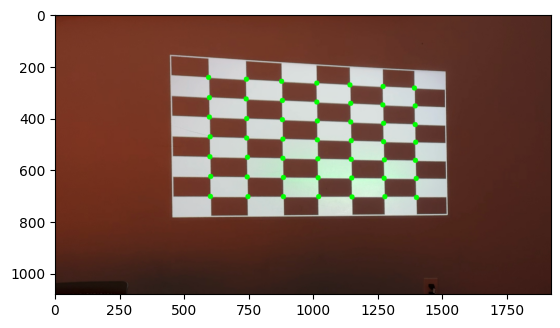

In [11]:
image_path = "sample_image.jpg"
# image_path = "extreme2.jpeg"
# image_path = "rotate_cb.jpg"
pattern_size = (8-1, 8-1)
width = 3839 # 16
height = 2159 # 9
r = width / height

orig_img = cv2.imread(image_path)
img = orig_img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, corners = cv2.findChessboardCorners(gray, pattern_size)

# Order of Corners: Always counterclockwise
if ret: # Corners exist
    for i in range(len(corners)):
        x = round(corners[i][0][0])
        y = round(corners[i][0][1])
        cv2.circle(img, (x, y), 10, (0, 255, 0), -1)
else: sys.stderr.write("No Chessboard detected.\n")

plt.imshow(img)

## Corner Detection
Make this more accurate.

In [12]:
# Find which index is the top-left corner.
img = orig_img.copy()
corners = corners.reshape((pattern_size[0], pattern_size[1], 2));

corner_i = [[0,0], [0,-1], [-1,-1], [-1,0]];
top_left = getTopLeft(corner_i, corners, pattern_size);

# 2D array then rotate corners matrix to get top-left corner to (0,0)
if(top_left == 3): k = -1; # k=-1 for clockwise 90 degrees.
elif(top_left == 2): k = -2; # 180 degrees.
elif(top_left == 1): k = -3; # clockwise 270 degrees.
else: k = 0;
corners = np.rot90(corners, k);

# Gets the outer corners.
det_corners = getOuterCorners(corners, img);

## Calculate Optimal Corners

In [13]:
# Given corners in order (TOP_LEFT, TOP_RIGHT, BOTTOM_RIGHT, BOTTOM_LEFT)
corners = det_corners

# --- Compute line equations (a, b, c) for each side ---
# Each side is between consecutive corners
lines = []
for i in range(len(corners)):
    p1 = corners[i]
    p2 = corners[(i + 1) % len(corners)]
    x1, y1 = p1
    x2, y2 = p2
    # Line coefficients a*x + b*y + c = 0
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    lines.append((a, b, c))

# Ensure inequality points *inside* the quadrilateral
# We'll orient all inequalities so that the polygon's centroid satisfies a*x + b*y + c < 0
centroid = np.mean(corners, axis=0)
for i, (a, b, c) in enumerate(lines):
    if a * centroid[0] + b * centroid[1] + c > 0:
        lines[i] = (-a, -b, -c)

# --- Define functions ---
def rectangle_corners(x0, y0, w, r):
    h = w / r
    xs = [x0 - w/2, x0 + w/2]
    ys = [y0 - h/2, y0 + h/2]
    return [(x, y) for x in xs for y in ys]  # 4 corners

def inside_constraints(params):
    x0, y0, w = params
    h = w / r
    xs = [x0 - w/2, x0 + w/2]
    ys = [y0 - h/2, y0 + h/2]
    corners_rect = [(x, y) for x in xs for y in ys]
    cons = []
    for (a, b, c) in lines:
        for (x, y) in corners_rect:
            cons.append(-(a*x + b*y + c))  # must be >= 0
    return np.array(cons)

# Objective: maximize area = w^2 / r -> minimize -w^2 / r
def objective(params):
    _, _, w = params
    return -w**2 / r

# Build constraint list
constraints = [{'type': 'ineq', 'fun': lambda p, i=i: inside_constraints(p)[i]} for i in range(16)]

# Initial guess: center of the quadrilateral, width about 1/3 of its bounding box
min_x, min_y = np.min(corners, axis=0)
max_x, max_y = np.max(corners, axis=0)
x0_guess = (min_x + max_x) / 2
y0_guess = (min_y + max_y) / 2
w_guess = (max_x - min_x) / 3
x0_init = [x0_guess, y0_guess, w_guess]

# Bounds for (x0, y0, w)
bounds = [(min_x, max_x), (min_y, max_y), (0, max_x - min_x)]

# Optimize
res = minimize(objective, x0_init, constraints=constraints, bounds=bounds, method='SLSQP')

# Results
x_best, y_best, w_best = res.x
h_best = w_best / r
A_best = w_best * h_best

rect_x = [x_best - w_best/2, x_best + w_best/2, x_best + w_best/2, x_best - w_best/2]
rect_y = [y_best - h_best/2, y_best - h_best/2, y_best + h_best/2, y_best + h_best/2]

In [14]:
opt_corners = [];
for i in range(len(rect_x)):
    x = rect_x[i];
    y = rect_y[i];
    opt_corners.append([x,y])

jpg_corners = [
    [0, 0],  # top-left
    [width, 0],  # top-right
    [width, height],  # bottom-right
    [0, height]  # bottom-left
]

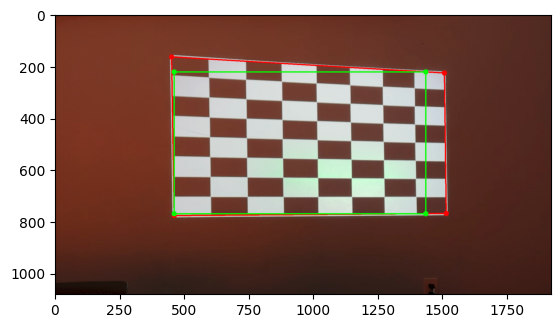

In [20]:
def draw_box(img, corners, color, radius=10, thickness=3):
    # Draw corner points
    for x, y in corners:
        cv2.circle(img, (round(x), round(y)), radius, color, -1)

    # Draw connecting lines
    for i in range(len(corners)):
        x1, y1 = map(round, corners[i])
        x2, y2 = map(round, corners[(i + 1) % len(corners)])
        cv2.line(img, (x1, y1), (x2, y2), color, thickness)

draw_box(img, det_corners, (255, 0, 0))   # red
draw_box(img, opt_corners, (0, 255, 0))   # green
plt.imshow(img)

In [9]:
# Homography matrix from Camera Space Uncorrected Corners -> DMD Space Uncorrected Corners.
H, _ = cv2.findHomography(
    np.array(det_corners), 
    np.array(jpg_corners)
)
opt_corners_np = np.array(opt_corners, dtype=np.float32).reshape(-1, 1, 2)
input_shape = cv2.perspectiveTransform(opt_corners_np, H).reshape(-1, 2)

corner_order = ["Top Left", "Top Right", "Bottom Right", "Bottom_Left"];
print(f"Optimal Corners")
for i in range(len(input_shape)):
    x =round(input_shape[i][0])
    y =round(input_shape[i][1])
    print(f"{corner_order[i]}: ({x},{y})")

print(f"\nOriginal Corners")
for i in range(len(input_shape)):
    x =round(jpg_corners[i][0])
    y =round(jpg_corners[i][1])
    print(f"{corner_order[i]}: ({x},{y})")

Optimal Corners
Top Left: (29,202)
Top Right: (3546,0)
Bottom Right: (3517,2159)
Bottom_Left: (0,2133)

Original Corners
Top Left: (0,0)
Top Right: (3839,0)
Bottom Right: (3839,2159)
Bottom_Left: (0,2159)


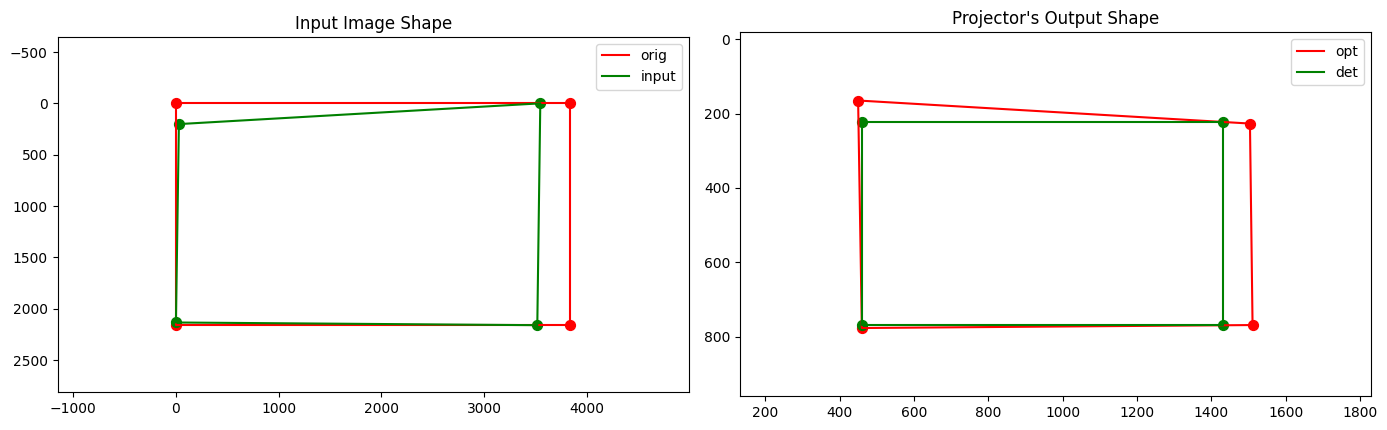

In [10]:
import numpy as np
import matplotlib.pyplot as plt

canvas_size = (4500, 4500)

def draw_shape(ax, corners, color, label, legend_loc='upper right'):
    corners = np.vstack([corners, corners[0]])  # close the loop
    ax.plot(corners[:, 0], corners[:, 1], color=color, label=label)
    for i, (x, y) in enumerate(corners[:-1]):
        ax.scatter(x, y, color=color, s=50)
        # ax.text(x + 10, y + 10, f'{label}[{i}]', fontsize=8, color=color)
    ax.set_aspect('equal')
    ax.legend(loc=legend_loc)

def set_axis_limits(ax, corners_list, margin=0):
    """
    Auto-scale axes to fit all corners in corners_list with extra leeway.
    margin: fraction of the data range to pad (e.g., 0.1 = 10%)
    """
    # Convert each list of (x,y) tuples to numpy arrays
    xs = np.concatenate([np.array(cg)[:, 0] for cg in corners_list])
    ys = np.concatenate([np.array(cg)[:, 1] for cg in corners_list])

    # Compute ranges
    x_range = xs.max() - xs.min()
    y_range = ys.max() - ys.min()

    # Add leeway
    ax.set_xlim(xs.min() - margin * x_range, xs.max() + margin * x_range)
    ax.set_ylim(ys.max() + margin * y_range, ys.min() - margin * y_range)  # flip y-axis


# Create 1x2 grid of subplots with equal size
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# Left subplot
draw_shape(axs[0], jpg_corners, 'red', 'orig')
draw_shape(axs[0], input_shape, 'green', 'input')
set_axis_limits(axs[0], [jpg_corners, input_shape], margin=0.3)
axs[0].set_title('Input Image Shape')

# Right subplot
draw_shape(axs[1], det_corners, 'red', 'opt')
draw_shape(axs[1], opt_corners, 'green', 'det')
set_axis_limits(axs[1], [opt_corners, det_corners], margin=0.3)
axs[1].set_title("Projector's Output Shape")

plt.tight_layout()
plt.show()